<a href="https://colab.research.google.com/github/audreynahir/analisis-tiendas.ipynb/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [15]:
import pandas as pd
import matplotlib.pyplot as plt

tienda["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

df = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

Tienda
Tienda 1    1.150880e+09
Tienda 2    1.116344e+09
Tienda 3    1.098020e+09
Tienda 4    1.038376e+09
Name: Precio, dtype: float64


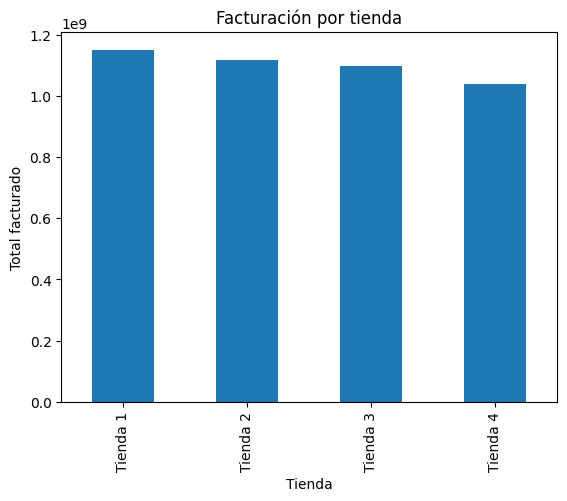

In [16]:
facturacion = df.groupby("Tienda")["Precio"].sum()

print(facturacion)

facturacion.plot(kind="bar", title="Facturación por tienda")
plt.ylabel("Total facturado")
plt.xlabel("Tienda")
plt.show()

# 2. Ventas por categoría

Categoría del Producto
Artículos para el hogar    5.757980e+07
Deportes y diversión       1.429777e+08
Electrodomésticos          1.324751e+09
Electrónicos               1.660576e+09
Instrumentos musicales     3.487726e+08
Juguetes                   7.360440e+07
Libros                     3.769610e+07
Muebles                    7.576610e+08
Name: Precio, dtype: float64


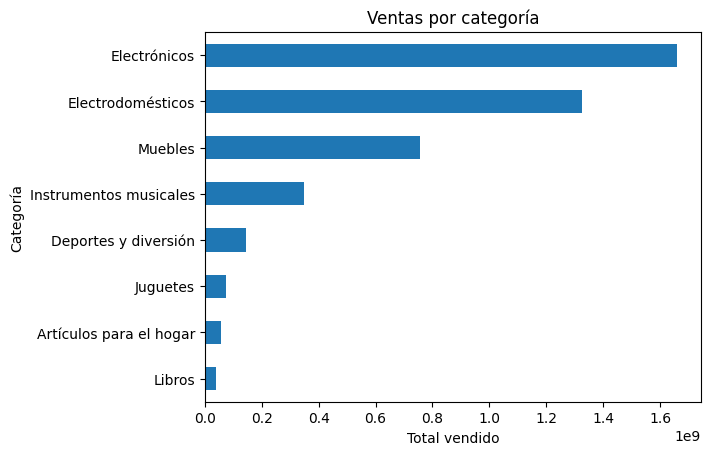

In [17]:
ventas_categoria = df.groupby("Categoría del Producto")["Precio"].sum()

print(ventas_categoria)

ventas_categoria.sort_values().plot(
    kind="barh",
    title="Ventas por categoría"
)

plt.xlabel("Total vendido")
plt.ylabel("Categoría")
plt.show()

# 3. Calificación promedio de la tienda


Tienda
Tienda 1    3.976685
Tienda 2    4.037304
Tienda 3    4.048326
Tienda 4    3.995759
Name: Calificación, dtype: float64


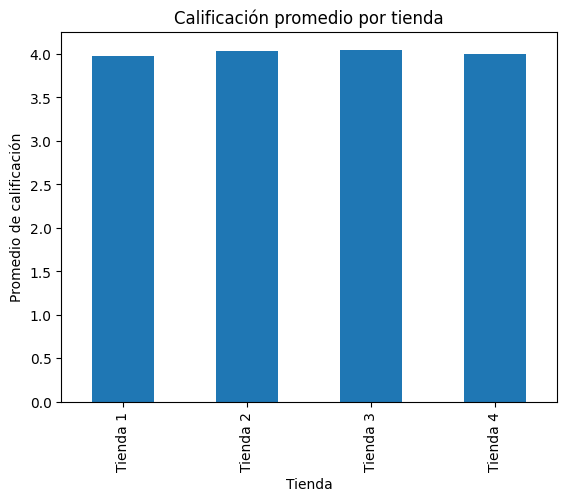

In [18]:
calificacion = df.groupby("Tienda")["Calificación"].mean()

print(calificacion)

calificacion.plot(
    kind="bar",
    title="Calificación promedio por tienda"
)

plt.ylabel("Promedio de calificación")
plt.xlabel("Tienda")
plt.show()

# 4. Productos más y menos vendidos

Producto
Mesa de noche                210
Carrito de control remoto    206
Microondas                   206
Batería                      203
Cama king                    201
Secadora de ropa             200
Modelado predictivo          200
Set de ollas                 200
Cama box                     199
Bloques de construcción      199
Name: count, dtype: int64


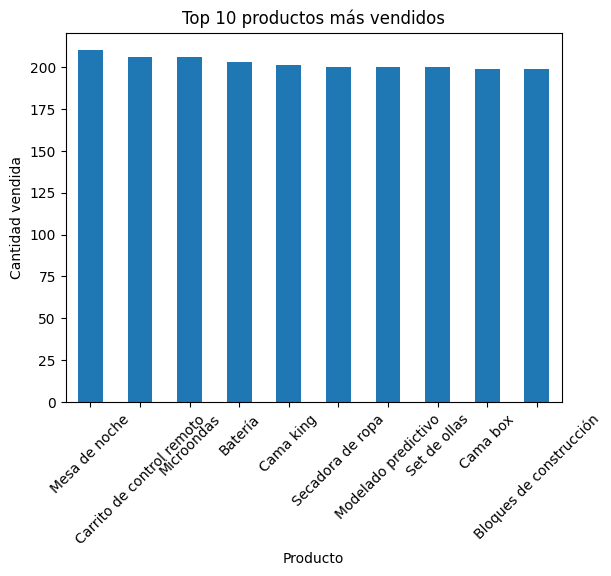

In [19]:
productos_vendidos = df["Producto"].value_counts().head(10)

print(productos_vendidos)

productos_vendidos.plot(
    kind="bar",
    title="Top 10 productos más vendidos"
)

plt.ylabel("Cantidad vendida")
plt.xlabel("Producto")
plt.xticks(rotation=45)
plt.show()

# 5. Envío promedio por tienda

Tienda
Tienda 1    26018.609580
Tienda 2    25216.235693
Tienda 3    24805.680373
Tienda 4    23459.457167
Name: Costo de envío, dtype: float64


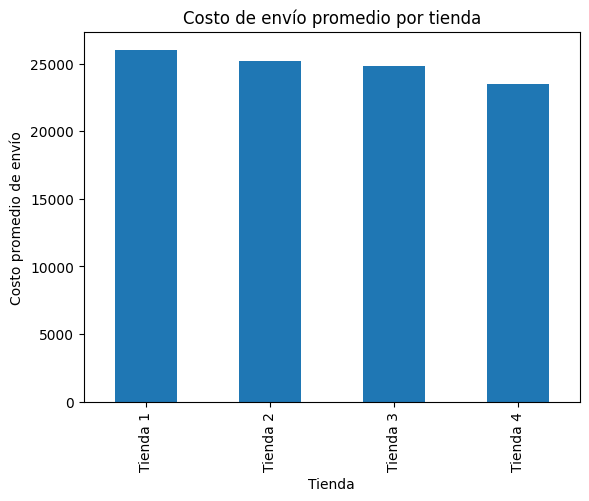

In [21]:
envio_promedio = df.groupby("Tienda")["Costo de envío"].mean()

print(envio_promedio)

envio_promedio.plot(
    kind="bar",
    title="Costo de envío promedio por tienda"
)

plt.ylabel("Costo promedio de envío")
plt.xlabel("Tienda")
plt.show()

# **Informe Final**

**Análisis de facturación**

El análisis de los ingresos muestra que la Tienda 1 presenta la mayor facturación total, con aproximadamente 1.150 millones, seguida por Tienda 2 con 1.116 millones, Tienda 3 con 1.098 millones y finalmente Tienda 4 con 1.038 millones.

Esto indica que la Tienda 1 es la que genera mayor volumen de ventas, lo que podría sugerir una mayor demanda o una mejor capacidad comercial.

**Ventas por categoría**

Las categorías que generan mayores ingresos son principalmente Electrónicos y Electrodomésticos, lo que indica una alta demanda de productos tecnológicos y de uso doméstico. Por otro lado, categorías como Libros, Juguetes y Artículos para el hogar presentan niveles de ventas considerablemente menores.

Este análisis permite identificar que las tiendas que tengan una mayor participación en la venta de productos tecnológicos probablemente generen mayores ingresos.

Calificación promedio de las tiendas
**texto en negrita**
En cuanto a la satisfacción de los clientes, las calificaciones promedio muestran valores relativamente similares entre las tiendas. Sin embargo, la Tienda 3 presenta la mejor calificación promedio con aproximadamente 4.05, seguida por Tienda 2 con 4.03, Tienda 4 con 3.99 y finalmente Tienda 1 con 3.98.

Esto sugiere que, aunque la Tienda 1 tiene mayores ingresos, la experiencia del cliente podría ser ligeramente mejor en la Tienda 3.

**Productos más vendidos**

Entre los productos más vendidos destacan Mesa de noche, Carrito de control remoto, Microondas, Batería y Cama king, todos con más de 200 ventas aproximadamente.

Estos productos pertenecen principalmente a las categorías de muebles, electrodomésticos y juguetes, lo cual coincide con las categorías de mayor actividad comercial dentro de las tiendas.

**Coste promedio de envío**

El análisis del costo promedio de envío muestra diferencias entre las tiendas. La Tienda 1 presenta el costo promedio más alto con aproximadamente 26,018, seguida por Tienda 2 con 25,216, Tienda 3 con 24,805, mientras que la Tienda 4 tiene el costo más bajo con 23,459.

Un costo de envío menor puede representar una ventaja competitiva, ya que puede incentivar a más clientes a realizar compras.

**Conclusión y recomendación**

Considerando todos los factores analizados, se observa que la Tienda 1 tiene la mayor facturación total, lo que indica un fuerte desempeño comercial y una alta demanda de productos. Sin embargo, también presenta el costo de envío promedio más alto y una calificación ligeramente inferior en comparación con otras tiendas.

Por otro lado, la Tienda 3 destaca por tener la mejor calificación promedio de los clientes y costos de envío relativamente moderados, aunque su facturación total es ligeramente menor que la de las tiendas líderes.

Tomando en cuenta el equilibrio entre ingresos, satisfacción del cliente y costos operativos, la Tienda 3 se presenta como una opción sólida, ya que combina una buena facturación con la mejor valoración por parte de los clientes y costos de envío más competitivos.

Por lo tanto, se recomienda que el Sr. Juan considere vender la Tienda 3, ya que ofrece un balance favorable entre rentabilidad, eficiencia operativa y satisfacción del cliente.